#  تحميل البيانات وفحصها الأولي

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
data = files.upload()  # ارفعي electricity_project_dataset_2years.xlsx


Saving electricity_project_dataset_2years.xlsx to electricity_project_dataset_2years.xlsx


In [ ]:
file_name = list(data.keys())[0]
df = pd.read_excel(file_name, sheet_name="بيانات الاستهلاك والفواتير")
df["الشهر"] = pd.to_datetime(df["الشهر"])
print(df.shape)
df.head()


(21615, 19)


,معرف الأسرة,الشهر,المحافظة,فئة الدخل,حجم الأسرة,يوجد تكييف,الاستهلاك (كيلووات ساعة),قيمة الفاتورة (جنيه) - تعريفة 2026,قيمة الفاتورة (جنيه) - سيناريو زيادة 15%,الفرق (جنيه),نوع السكن,عدد الغرف,نوع العداد,نوع المنطقة,حالة سداد الفاتورة,عدد مرات انقطاع الكهرباء,عدد الأجهزة الكهربائية الكبيرة,درجة الحرارة المتوسطة (م),رقم المحول الكهربائي
0,HH-0001,2024-08-01,الشرقية,فوق المتوسط,6,لا,713,1116.38,1282.82,166.44,شقة,7.0,عداد كودي (مسبق الدفع),حضر,مدفوعة في الموعد,2,5.0,33.0,TR-SHR-01
1,HH-0001,2024-09-01,الشرقية,فوق المتوسط,6,لا,640,964.73,1108.14,143.41,شقة,7.0,عداد كودي (مسبق الدفع),حضر,مدفوعة في الموعد,0,5.0,31.0,TR-SHR-01
2,HH-0001,2024-10-01,الشرقية,فوق المتوسط,6,لا,672,1030.28,1183.60,153.32,شقة,7.0,عداد كودي (مسبق الدفع),حضر,مدفوعة في الموعد,1,5.0,27.0,TR-SHR-01
3,HH-0001,2024-11-01,الشرقية,فوق المتوسط,6,لا,479,650.78,747.50,96.72,شقة,7.0,عداد كودي (مسبق الدفع),حضر,مدفوعة في الموعد,0,5.0,22.0,TR-SHR-01
4,HH-0001,2024-12-01,الشرقية,فوق المتوسط,6,لا,606,898.43,1031.98,133.55,شقة,7.0,عداد كودي (مسبق الدفع),حضر,مدفوعة في الموعد,1,5.0,17.0,TR-SHR-01


In [ ]:
df.dtypes

,0
معرف الأسرة,object
الشهر,datetime64[ns]
المحافظة,object
فئة الدخل,object
حجم الأسرة,int64
يوجد تكييف,object
الاستهلاك (كيلووات ساعة),int64
قيمة الفاتورة (جنيه) - تعريفة 2026,float64
قيمة الفاتورة (جنيه) - سيناريو زيادة 15%,float64
الفرق (جنيه),float64


In [ ]:
print(df.isna().sum())

معرف الأسرة                                   0
الشهر                                         0
المحافظة                                      0
فئة الدخل                                     0
حجم الأسرة                                    0
يوجد تكييف                                  120
الاستهلاك (كيلووات ساعة)                      0
قيمة الفاتورة (جنيه) - تعريفة 2026            0
قيمة الفاتورة (جنيه) - سيناريو زيادة 15%      0
الفرق (جنيه)                                  0
نوع السكن                                     0
عدد الغرف                                    10
نوع العداد                                    0
نوع المنطقة                                   0
حالة سداد الفاتورة                            0
عدد مرات انقطاع الكهرباء                      0
عدد الأجهزة الكهربائية الكبيرة              150
درجة الحرارة المتوسطة (م)                   181
رقم المحول الكهربائي                          0
dtype: int64


In [ ]:
print(df.duplicated().sum())

15


In [ ]:
df['المحافظة'].unique()

array(['الشرقية', 'الجيزة', 'الإسكندرية', 'الدقهلية', 'المنوفية',
       'الجيزة ', 'أسيوط', 'القاهرة', 'القاهره', ' القاهرة', 'cairo',
       ' الجيزة', 'الجيزه'], dtype=object)

In [ ]:
df['نوع السكن'].unique()

array(['شقة', 'فيلا', 'دور في منزل', 'فيلّا', 'شقه'], dtype=object)

#  تنظيف البيانات

##  إزالة الصفوف المكررة

In [ ]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"عدد الصفوف قبل الحذف: {n_before}")
print(f"عدد الصفوف بعد الحذف: {len(df)}")


عدد الصفوف قبل الحذف: 21615
عدد الصفوف بعد الحذف: 21600


##  توحيد النصوص غير المتسقة

In [ ]:
governorate_fix_map = {
    "الجيزه": "الجيزة", " الجيزة": "الجيزة", "الجيزة ": "الجيزة",
    "القاهره": "القاهرة", " القاهرة": "القاهرة", "cairo": "القاهرة",
}
housing_fix_map = {"شقه": "شقة", "فيلّا": "فيلا"}

df["المحافظة"] = df["المحافظة"].astype(str).str.strip().replace(governorate_fix_map)
df["نوع السكن"] = df["نوع السكن"].astype(str).str.strip().replace(housing_fix_map)

print(df["المحافظة"].unique())
print(df["نوع السكن"].unique())


['الشرقية' 'الجيزة' 'الإسكندرية' 'الدقهلية' 'المنوفية' 'أسيوط' 'القاهرة']
['شقة' 'فيلا' 'دور في منزل']


##  تصحيح نوع البيانات (عدد الغرف)

In [ ]:
df["عدد الغرف"] = pd.to_numeric(df["عدد الغرف"], errors="coerce")
df["عدد الغرف"] = df.groupby("حجم الأسرة")["عدد الغرف"].transform(lambda s: s.fillna(s.median()))
df["عدد الغرف"] = df["عدد الغرف"].astype(int)
print("القيم الناقصة المتبقية:", df["عدد الغرف"].isna().sum())


القيم الناقصة المتبقية: 0


##  معالجة القيم الشاذة في الاستهلاك

In [ ]:
n_before = len(df)
invalid_mask = (df["الاستهلاك (كيلووات ساعة)"] < 0) | (df["الاستهلاك (كيلووات ساعة)"] > 3000)
print(f"عدد القيم غير المنطقية: {invalid_mask.sum()}")

df = df.loc[~invalid_mask].reset_index(drop=True)
print(f"عدد الصفوف قبل: {n_before}   |   بعد: {len(df)}")


عدد القيم غير المنطقية: 8
عدد الصفوف قبل: 21600   |   بعد: 21592


##  معالجة القيم الناقصة

In [ ]:
df["درجة الحرارة المتوسطة (م)"] = df.groupby(["المحافظة", "الشهر"])["درجة الحرارة المتوسطة (م)"].transform(
    lambda s: s.fillna(s.mean())
)
df["عدد الأجهزة الكهربائية الكبيرة"] = df.groupby("فئة الدخل")["عدد الأجهزة الكهربائية الكبيرة"].transform(
    lambda s: s.fillna(s.median())
)
df["يوجد تكييف"] = df.groupby("معرف الأسرة")["يوجد تكييف"].transform(
    lambda s: s.fillna(s.mode().iloc[0]) if not s.mode().empty else s
)
df["يوجد تكييف"] = df["يوجد تكييف"].fillna(df["يوجد تكييف"].mode().iloc[0])

print("قيم ناقصة متبقية في الداتا كلها:", df.isna().sum().sum())


قيم ناقصة متبقية في الداتا كلها: 0


#  هندسة الخصائص (Feature Engineering)

In [ ]:
target = "قيمة الفاتورة (جنيه) - تعريفة 2026"
usage_col = "الاستهلاك (كيلووات ساعة)"

df = df.sort_values(["معرف الأسرة", "الشهر"]).reset_index(drop=True)

df["month_sin"] = np.sin(2 * np.pi * df["الشهر"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["الشهر"].dt.month / 12)
df["هل_ذروة_صيف"] = df["الشهر"].dt.month.isin([6,7,8]).astype(int)

g = df.groupby("معرف الأسرة")
df["usage_1"] = g[usage_col].shift(1)
df["usage_2"] = g[usage_col].shift(2)
df["usage_3"] = g[usage_col].shift(3)
df["bill_1"] = g[target].shift(1)
df["bill_2"] = g[target].shift(2)
df["bill_3"] = g[target].shift(3)
df["usage_avg3"] = (df["usage_1"] + df["usage_2"] + df["usage_3"]) / 3

df = df.dropna(subset=["usage_1", "usage_2", "usage_3"]).reset_index(drop=True)
print(df.shape)


(18892, 29)


#  تقسيم البيانات (Train/Test)




In [ ]:
df["rank"] = df.groupby("معرف الأسرة")["الشهر"].rank(method="first", ascending=False)

test_raw = df[df["rank"] <= 2].copy()
train_raw = df[df["rank"] > 2].copy()

numeric_features = [
    "usage_1", "usage_2", "usage_3", "bill_1", "bill_2", "bill_3", "usage_avg3",
    "حجم الأسرة", "عدد الأجهزة الكهربائية الكبيرة", "درجة الحرارة المتوسطة (م)",
    "عدد الغرف", "هل_ذروة_صيف", "month_sin", "month_cos",
    "عدد مرات انقطاع الكهرباء",
]
categorical_features = ["فئة الدخل", "يوجد تكييف", "نوع السكن", "المحافظة"]

X_train_raw = train_raw[numeric_features + categorical_features]
y_train = train_raw[target]
X_test_raw = test_raw[numeric_features + categorical_features]
y_test = test_raw[target]
bill_1_test = test_raw["bill_1"]

print("عدد صفوف التدريب:", len(X_train_raw))
print("عدد صفوف الاختبار:", len(X_test_raw))


عدد صفوف التدريب: 17092
عدد صفوف الاختبار: 1800


#  بناء Pipeline المعالجة (Imputation + Encoding)



In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])


# Baseline Model



In [ ]:

baseline_preds = bill_1_test

mae_baseline = mean_absolute_error(y_test, baseline_preds)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))
r2_baseline = r2_score(y_test, baseline_preds)

print("MAE:", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("R2:", round(r2_baseline, 3))


MAE: 209.99
RMSE: 326.24
R2: 0.726


# Random Forest Regressor



In [ ]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1))
])

final_pipeline.fit(X_train_raw, y_train)
preds = final_pipeline.predict(X_test_raw)
train_preds = final_pipeline.predict(X_train_raw)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
r2_train = r2_score(y_train, train_preds)

print("R2 على التدريب:", round(r2_train, 3))
print("R2 على الاختبار:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


R2 على التدريب: 0.924
R2 على الاختبار: 0.916
MAE: 120.29
RMSE: 180.45


## مقارنة الموديل النهائي بالـ Baseline

In [ ]:
comparison = pd.DataFrame([
    {"Model": "Baseline", "MAE": round(mae_baseline, 2), "RMSE": round(rmse_baseline, 2), "R2": round(r2_baseline, 3)},
    {"Model": "Random Forest", "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 3)},
])
comparison


,Model,MAE,RMSE,R2
0,Baseline,209.99,326.24,0.726
1,Random Forest,120.29,180.45,0.916


## أهم العوامل المؤثرة على التنبؤ

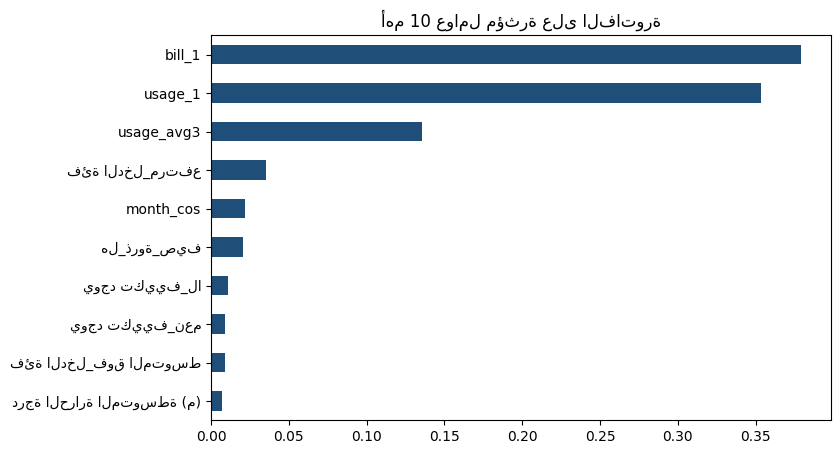

In [ ]:
ohe_cols = final_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

importances = final_pipeline.named_steps["regressor"].feature_importances_
imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)[:10]

imp_series[::-1].plot(kind="barh", figsize=(8,5), color="#1F4E78")
plt.title("أهم 10 عوامل مؤثرة على الفاتورة")
plt.show()


# 9) استخدام الموديل للتنبؤ بحالة جديدة

In [ ]:
def predict_new_case(
    usage_1, usage_2, usage_3, bill_1, bill_2, bill_3,
    family_size, appliance_count, avg_temp, rooms, outage_count,
    income_level, has_ac, housing_type, governorate, is_summer_peak, month_number
):
    raw = {
        "usage_1": usage_1, "usage_2": usage_2, "usage_3": usage_3,
        "bill_1": bill_1, "bill_2": bill_2, "bill_3": bill_3,
        "usage_avg3": (usage_1 + usage_2 + usage_3) / 3,
        "حجم الأسرة": family_size,
        "عدد الأجهزة الكهربائية الكبيرة": appliance_count,
        "درجة الحرارة المتوسطة (م)": avg_temp,
        "عدد الغرف": rooms,
        "هل_ذروة_صيف": is_summer_peak,
        "month_sin": np.sin(2 * np.pi * month_number / 12),
        "month_cos": np.cos(2 * np.pi * month_number / 12),
        "عدد مرات انقطاع الكهرباء": outage_count,
        "فئة الدخل": income_level,
        "يوجد تكييف": has_ac,
        "نوع السكن": housing_type,
        "المحافظة": governorate,
    }
    row = pd.DataFrame([raw])[numeric_features + categorical_features]
    return round(final_pipeline.predict(row)[0], 2)


example = predict_new_case(
    usage_1=350, usage_2=320, usage_3=310, bill_1=430, bill_2=390, bill_3=380,
    family_size=5, appliance_count=4, avg_temp=33, rooms=5, outage_count=1,
    income_level="متوسط", has_ac="نعم", housing_type="شقة", governorate="القاهرة",
    is_summer_peak=1, month_number=7
)
print(f"الفاتورة المتوقعة: {example} جنيه")


الفاتورة المتوقعة: 501.75 جنيه


In [ ]:
#df.to_csv("Electricity_cleaned.csv", index=False,encoding="utf-8-sig")

# Download the cleaned file
#from google.colab import files
#files.download("Electricity_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

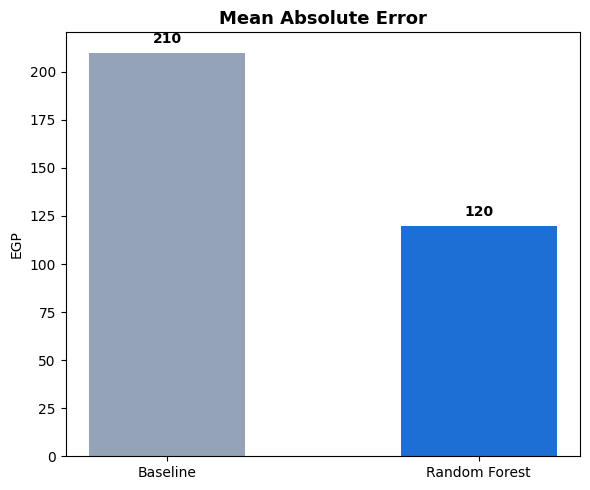

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline", "Random Forest"]
mae_values = [210, 120]
colors = ["#94a3b8", "#1d6fd6"]
plt.figure(figsize=(6, 5))
bars = plt.bar(models, mae_values, color=colors, width=0.5)
plt.title("Mean Absolute Error", fontsize=13, fontweight="bold")
plt.ylabel("EGP")

for bar, val in zip(bars, mae_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5, f"{val}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("mae_comparison.png", dpi=200)
plt.show()